<a href="https://colab.research.google.com/github/uvindu827/mushroom-classifer-app/blob/main/mushroom_classifier_v1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [23]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
from sklearn.metrics import classification_report
from sklearn.metrics._plot.confusion_matrix import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [24]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"✅ SUCCESS: GPU is available: {gpus[0].name}")
else:
    print("❌ WARNING: You are using CPU. Go to Runtime -> Change runtime type -> T4 GPU")

✅ SUCCESS: GPU is available: /physical_device:GPU:0


#Loading data

In [25]:
dataset_path = '/content/drive/MyDrive/Mushroom-project/Sri Lankan mushroom species.v3i.folder'
BATCH_SIZE = 32
IMG_SIZE = (224, 224)


In [26]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    f'{dataset_path}/train',
    shuffle = True,
    image_size = IMG_SIZE,
    batch_size = BATCH_SIZE
)

valid_ds = tf.keras.utils.image_dataset_from_directory(
    f'{dataset_path}/valid',
    shuffle = True,
    image_size = IMG_SIZE,
    batch_size = BATCH_SIZE
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    f'{dataset_path}/test',
    shuffle = True,
    image_size = IMG_SIZE,
    batch_size = BATCH_SIZE
)

class_names = train_ds.class_names
print("\n\nMushroom classes:")
for mushroom_class in class_names:
    print(f'\t{mushroom_class}')

train_ds = train_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)
valid_ds = valid_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

Found 1251 files belonging to 13 classes.
Found 122 files belonging to 13 classes.
Found 61 files belonging to 13 classes.


Mushroom classes:
	Idalolu
	Muthu beli bimmal
	boththam hathu
	goma hathu
	heenvali hathu
	kotan hathu
	kurulu thuda bimmal
	leena hathu
	mahaveli hathu
	nayi hathu
	piduru hathu
	rathu hathu
	uru hathu


#Data Augmentation

In [27]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2)
])

#Model Architecture

In [28]:
base_model = tf.keras.applications.MobileNetV3Small(
    input_shape = IMG_SIZE + (3,),
    include_top = False,
    weights = 'imagenet'
)

base_model.trainable = False

In [29]:
inputs = tf.keras.Input(shape=IMG_SIZE + (3,))
x = data_augmentation(inputs)
x = tf.keras.applications.mobilenet_v3.preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(len(class_names), activation='softmax')(x)

model = models.Model(inputs, outputs)

In [30]:
model.compile(
    optimizer = 'adam',
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

In [31]:
history = model.fit(
    train_ds,
    validation_data = valid_ds,
    epochs = 10
)

Epoch 1/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 13s 174ms/step - accuracy: 0.1708 - loss: 2.6372 - val_accuracy: 0.5656 - val_loss: 1.6861
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.5648 - loss: 1.5315 - val_accuracy: 0.6393 - val_loss: 1.2830
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.6596 - loss: 1.1277 - val_accuracy: 0.6639 - val_loss: 1.1080
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.7577 - loss: 0.8840 - val_accuracy: 0.7049 - val_loss: 0.9939
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.7838 - loss: 0.7666 - val_accuracy: 0.7049 - val_loss: 0.9374
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.8224 - loss: 0.6498 - val_accuracy: 0.7213 - val_loss: 0.8883
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.8296 - loss: 0.5985 - val_accuracy: 0.7459 - val_loss: 0.8572
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.8733 - loss: 0.5221 - val_accuracy: 0.7459 -

#Evaluation

In [32]:
pred = model.predict(test_ds)
y_pred = np.argmax(pred, axis=1)

2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step


In [33]:
y_true = []

for images, labels in test_ds:
  y_true.extend(labels.numpy())



- Classification report

In [34]:
classification_report = classification_report(y_true, y_pred)
print(classification_report)

              precision    recall  f1-score   support

           0       1.00      0.33      0.50         6
           1       0.67      0.67      0.67         3
           2       0.67      1.00      0.80         2
           3       0.85      0.92      0.88        12
           4       0.50      0.75      0.60         4
           5       1.00      0.86      0.92         7
           6       1.00      0.50      0.67         2
           7       0.00      0.00      0.00         1
           8       0.67      0.50      0.57         4
           9       1.00      1.00      1.00         7
          10       0.50      0.75      0.60         4
          11       1.00      1.00      1.00         5
          12       0.67      1.00      0.80         4

    accuracy                           0.79        61
   macro avg       0.73      0.71      0.69        61
weighted avg       0.82      0.79      0.77        61



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


- Confusion matrix

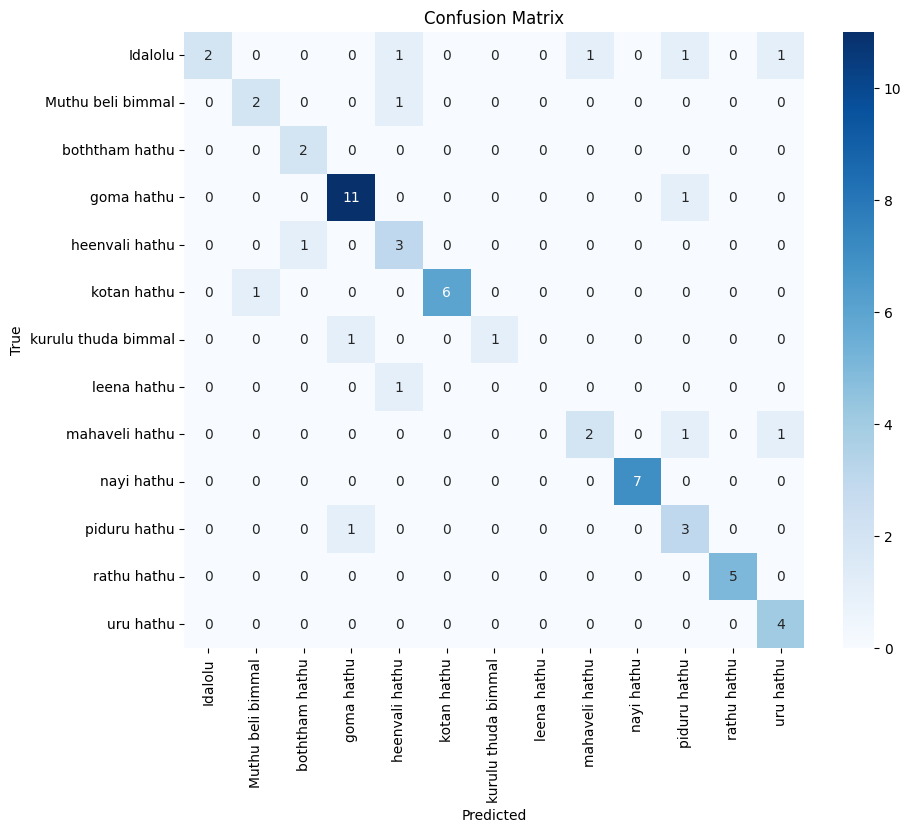

In [35]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

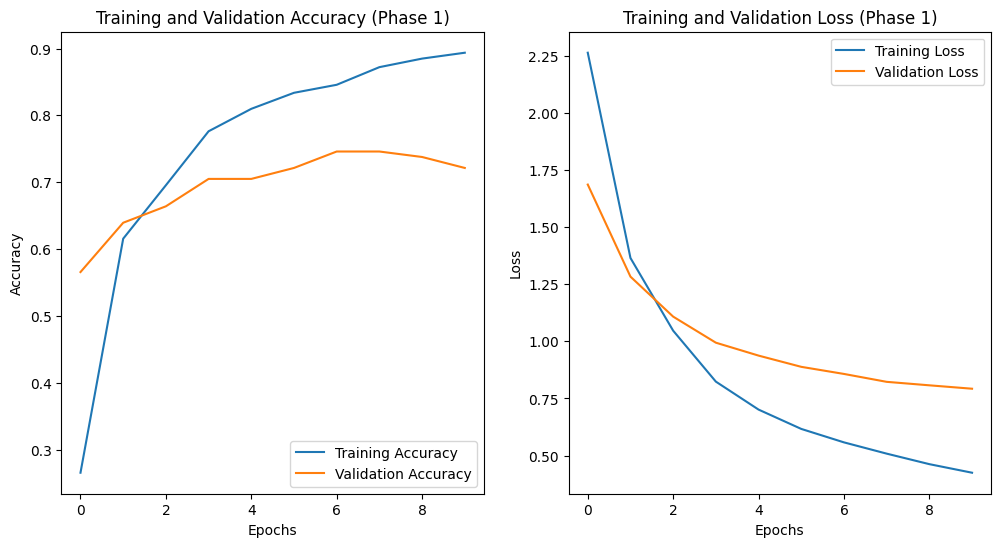

In [36]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

# 2. Setup the plot
plt.figure(figsize=(12, 6))

# --- Plot Accuracy ---
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')

# --- Plot Loss ---
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.show()